# 🇨🇴 Análisis de Generación Eléctrica — Colombia (API XM)

**Proyecto:** Energy Data Analysis Portfolio — Solar Generation Colombia  
**Versión:** 1.1  
**Autor:** Manuel Fernando Fajardo Rodríguez — Senior Electrical Engineer  
**Fuente de datos:** [API pública de XM](https://github.com/EquipoAnaliticaXM/API_XM) (Operador del Mercado Eléctrico Colombiano) vía `pydataxm`

---

## 🎯 Objetivo

Construir un **pipeline ETL reproducible** que extrae datos de generación eléctrica por recurso desde la API de XM, los transforma en un **modelo dimensional limpio** (star schema), y entrega un análisis exploratorio del parque generador del Sistema Interconectado Nacional (SIN) de Colombia.

**Preguntas que responde este notebook:**
1. ¿Cómo se distribuye la generación por tecnología (Solar, Hidráulica, Térmica, Eólica)?
2. ¿Cuál es el perfil horario típico de generación solar y su complementariedad con la hidráulica?
3. ¿Qué tan concentrado está el mercado por agente generador?
4. ¿Cuál es la composición real del parque solar por tipo de recurso (CREG)?

---

## 📂 Estructura del Repositorio

```
solar-generation-colombia/
├── notebooks/
│   └── 01_ETL_exploracion_v1.ipynb       ← Notebook proyecto v1
├── src/
│   ├── extraccion.py                      # Funciones de descarga desde la API XM
│   ├── etl.py                             # Pipeline de transformación (wide → long)
│   └── visualizaciones.py                 # Funciones de gráficos reutilizables
├── data/
│   ├── raw/                               # Datos crudos con estampa YYYYMMDD
│   │   ├── datos_generacion_YYYYMMDD.csv
│   │   ├── dim_plantas_YYYYMMDD.csv
│   │   ├── dim_agentes_YYYYMMDD.csv
│   │   └── dim_rios_YYYYMMDD.csv
│   └── processed/                         # Outputs limpios del ETL
│       ├── fact_generacion_YYYYMMDD.csv
│       ├── generacion_enriquecida_YYYYMMDD.csv
│       └── dim_plantas_clean_YYYYMMDD.csv
├── app/                                    # Dashboard Streamlit (v4 — futuro)
├── .gitignore
├── README.md
└── requirements.txt
```

---

## 📋 Contexto: Mercado Eléctrico Colombiano

**XM S.A. E.S.P.** opera el Sistema Interconectado Nacional (SIN) y administra el Mercado de Energía Mayorista (MEM) de Colombia. La métrica `Gene` (Generación Real) reporta la energía producida en **kWh** por cada recurso generador, en bloques horarios (H01–H24) para cada día.

| Tecnología | Participación aprox. | Rol en el sistema |
|:-----------|:---------------------|:------------------|
| 🌊 **Hidráulica** | ~65% de la energía | Base del sistema. Sensible a El Niño (aportes hídricos) |
| 🔥 **Térmica** | ~28% de la energía | Respaldo: gas natural, carbón, fuel oil. Define precio de bolsa |
| ☀️ **Solar** | ~3% energía, ~50% en número de recursos | Crecimiento en GD y autogeneración (CREG 174-2021) |
| 💨 **Eólica** | <1% (en expansión) | Proyectos en La Guajira |
| ⚙️ **Cogeneración** | ~3% | Industria azucarera (bagazo), sector industrial |

---
## ⚙️ Sección 0 — Instalación y Configuración

Dependencias principales: `pydataxm` (wrapper de la API XM), `pandas`, `matplotlib`, `seaborn`.  
El notebook detecta automáticamente si `pydataxm` está instalado y ajusta el modo de operación.

In [1]:
# Instalación (solo necesaria una vez en entornos nuevos)
%pip install pydataxm pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime as dt
import os

# Intentamos importar pydataxm — si no está disponible, el notebook carga los CSVs de data/raw/
try:
    from pydataxm import pydataxm
    API_DISPONIBLE = True
    print("✅ pydataxm disponible — se puede conectar a la API en vivo.")
except ImportError:
    API_DISPONIBLE = False
    print("ℹ️  pydataxm no instalado — el notebook usará los archivos CSV de data/raw/.")

# Configuración global de visualizaciones
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# Rutas base del proyecto (ajusta si mueves el notebook)
BASE_DIR = os.path.join("..")  # raíz del proyecto desde notebooks/
RAW_DIR  = os.path.join(BASE_DIR, "data", "raw")
OUT_DIR  = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(OUT_DIR, exist_ok=True)

print(f"\n📁 Directorio de salida: {OUT_DIR}")

✅ pydataxm disponible — se puede conectar a la API en vivo.

📁 Directorio de salida: ../data/processed


---
## 📥 Sección 1 — Extracción de Datos (API XM)

La función `obtener_generacion()` descarga la métrica **`Gene`** (Generación Real) desde la API pública de XM.

| Parámetro | Valor |
|:----------|:------|
| **Métrica** | `Gene` — Generación Real |
| **Nivel** | `Recurso` — una fila por planta generadora por día |
| **Formato** | Wide: 24 columnas (`Values_Hour01`...`Values_Hour24`) por fila |
| **Límite API** | Máximo **31 días** por llamada |
| **Tolerancia a fallos** | 3 reintentos con `time.sleep(2)` ante errores de red |

### Modos de operación

El notebook soporta 3 modos para máxima flexibilidad:

| Modo | Descripción | Requiere API |
|:-----|:------------|:-------------|
| `API` | Descarga los últimos 30 días (D-1) automáticamente | ✅ |
| `FIJO` | Rango de fechas personalizado (eventos históricos: El Niño, expansión solar) | ✅ |
| `CSV` | Carga archivos locales desde `data/raw/` — ideal para desarrollo sin conexión | ❌ |

In [3]:
import time

def obtener_generacion(fecha_inicio: dt.date, fecha_fin: dt.date) -> pd.DataFrame:
    """
    Descarga la generación real (métrica 'Gene') de todos los recursos del SIN
    desde la API de XM para el rango de fechas indicado.

    Args:
        fecha_inicio: Fecha de inicio (inclusive).
        fecha_fin:    Fecha de fin (inclusive). Máximo 31 días desde fecha_inicio.

    Returns:
        DataFrame con columnas: [Id, Values_code, Values_Hour01...Values_Hour24, Date]
        Retorna DataFrame vacío si la descarga falla.
    """
    MAX_DIAS = 31
    diferencia = (fecha_fin - fecha_inicio).days

    # Guard: ajuste automático si el rango excede el límite
    if diferencia > MAX_DIAS:
        print(f"⚠️  Rango de {diferencia} días supera el límite. Ajustando a {MAX_DIAS} días.")
        fecha_inicio = fecha_fin - dt.timedelta(days=MAX_DIAS)

    api_xm = pydataxm.ReadDB()
    rango   = pd.date_range(start=fecha_inicio, end=fecha_fin)
    bloques = []

    print(f"🔄 Descargando 'Gene' del {fecha_inicio} al {fecha_fin} ({len(rango)} días)...")

    for fecha in rango:
        f = fecha.date()
        for intento in range(3):  # Hasta 3 reintentos por día
            try:
                df_dia = api_xm.request_data("Gene", "Recurso", f, f)
                if df_dia is not None and not df_dia.empty:
                    bloques.append(df_dia)
                break  # Éxito — salir del loop de reintentos
            except Exception as e:
                if intento < 2:
                    time.sleep(2)
                else:
                    print(f"  ❌ Falló {f} tras 3 intentos: {e}")

    if not bloques:
        print("⚠️  No se obtuvieron datos. Retornando DataFrame vacío.")
        return pd.DataFrame()

    df_total = pd.concat(bloques, ignore_index=True)
    print(f"✅ Descarga completa — {df_total.shape[0]} filas, {df_total['Values_code'].nunique()} recursos únicos.")
    return df_total

In [4]:
"""
─── MODOS DE OPERACIÓN ──────────────────────────────────────────────────────
Se puede trabajar entre 3 modos:

 MODO = "API"     Descarga los últimos 30 días (D-1) desde la API de XM.
                  Requiere: pydataxm instalado.

 MODO = "FIJO"    Descarga un rango de fechas específico desde la API.
                  Útil para analizar eventos históricos: El Niño,
                  racionamientos, expansión de renovables, etc.
                  Requiere: pydataxm instalado. Máximo 31 días por rango.
                  ⚠️  Para períodos > 31 días descarga por bloques y usa
                      pd.concat() para unirlos.

 MODO = "CSV"     Carga el archivo datos_generacion_*.csv más reciente
                  disponible en data/raw/. No requiere conexión.
                  Ideal para desarrollo offline.

── Configuración exclusiva de MODO = "FIJO" ─────────────────────────────────

Referencia de períodos de interés del SIN colombiano:
  Niño 2023-2024 (bajo embalses)  → FECHA_INICIO_FIJO = dt.date(2024, 1, 1)
                                     FECHA_FIN_FIJO    = dt.date(2024, 1, 31)
  Expansión solar 2024            → FECHA_INICIO_FIJO = dt.date(2024, 6, 1)
                                     FECHA_FIN_FIJO    = dt.date(2024, 6, 30)
  Niño 2015-2016 (muy fuerte)     → FECHA_INICIO_FIJO = dt.date(2016, 1, 1)
                                     FECHA_FIN_FIJO    = dt.date(2016, 1, 31)

"""
MODO = "CSV"   # Opciones: "API" | "FIJO" | "CSV"


FECHA_INICIO_FIJO = dt.date(2026, 1, 1)
FECHA_FIN_FIJO    = dt.date(2026, 1, 31)
# ─────────────────────────────────────────────────────────────────────────────

if MODO == "API" and API_DISPONIBLE:
    # D-1: el mercado trabaja con el día anterior (hoy aún no está liquidado)
    fecha_fin    = dt.date.today() - dt.timedelta(days=1)
    fecha_inicio = fecha_fin - dt.timedelta(days=30)
    df_crudo = obtener_generacion(fecha_inicio, fecha_fin)

    if not df_crudo.empty:
        ts          = dt.datetime.now().strftime("%Y%m%d")
        ruta_salida = os.path.join(RAW_DIR, f"datos_generacion_{ts}.csv")
        df_crudo.to_csv(ruta_salida, index=False)
        print(f"💾 Datos guardados en: {ruta_salida}")

elif MODO == "FIJO" and API_DISPONIBLE:
    df_crudo = obtener_generacion(FECHA_INICIO_FIJO, FECHA_FIN_FIJO)

    if not df_crudo.empty:
        etiqueta    = f"{FECHA_INICIO_FIJO}_{FECHA_FIN_FIJO}"
        ruta_salida = os.path.join(RAW_DIR, f"datos_generacion_{etiqueta}.csv")
        df_crudo.to_csv(ruta_salida, index=False)
        print(f"💾 Datos guardados en: {ruta_salida}")

else:
    # Modo CSV: busca el archivo datos_generacion_*.csv más reciente en data/raw/
    import glob
    patron = os.path.join(RAW_DIR, "datos_generacion_*.csv")
    archivos = sorted(glob.glob(patron))
    if not archivos:
        raise FileNotFoundError(
            f"No se encontraron archivos datos_generacion_*.csv en {RAW_DIR}.\n"
            f"Ejecuta primero con MODO='API' para descargar datos, o coloca un CSV manualmente."
        )
    ruta_csv = archivos[-1]  # El último alfabéticamente = fecha más reciente (YYYYMMDD)
    df_crudo = pd.read_csv(ruta_csv)
    print(f"📂 Datos cargados desde: {os.path.basename(ruta_csv)}")
    print(f"   {df_crudo.shape[0]:,} filas, {df_crudo['Values_code'].nunique()} recursos únicos.")
    print(f"   Período: {df_crudo['Date'].min()} → {df_crudo['Date'].max()}")

df_crudo.head(3)

📂 Datos cargados desde: datos_generacion_20260610.csv
   13,276 filas, 506 recursos únicos.
   Período: 2026-05-10 → 2026-06-07


,Id,Values_code,Values_Hour01,Values_Hour02,Values_Hour03,Values_Hour04,Values_Hour05,Values_Hour06,Values_Hour07,Values_Hour08,...,Values_Hour16,Values_Hour17,Values_Hour18,Values_Hour19,Values_Hour20,Values_Hour21,Values_Hour22,Values_Hour23,Values_Hour24,Date
0,Recurso,2QBW,17798.98,17738.21,17703.92,17660.57,17634.11,17599.83,17534.55,17508.01,...,16983.96,16898.16,17217.55,16873.82,16935.08,16861.32,16857.68,16768.21,16642.29,2026-05-10
1,Recurso,2QEK,15066.23,15063.59,15059.88,15072.16,15070.92,15061.82,15073.15,15069.12,...,15054.85,15056.66,15046.54,15057.81,15051.00,15054.95,6412.63,NaN,NaN,2026-05-10
2,Recurso,2QRL,658.11,658.14,657.90,657.81,657.99,658.08,657.99,656.31,...,655.95,656.49,656.55,657.51,657.45,610.59,657.93,658.17,658.05,2026-05-10


---
## 📚 Sección 2 — Catálogos Maestros (Dimensiones)

Los catálogos maestros son las **tablas de dimensión** del modelo dimensional (star schema):

| Catálogo | API Metric | Llave | Descripción |
|:---------|:-----------|:------|:------------|
| `dim_plantas` | `ListadoRecursos` | `Values_Code` | Tecnología, fuente de energía, tipo de despacho, agente propietario |
| `dim_agentes` | `ListadoAgentes` | `Values_Code` | Empresas participantes del MEM |
| `dim_rios` | `ListadoRios` | `Values_Code` | Cuencas hidrográficas asociadas a plantas hidráulicas |

Los archivos se guardan con estampa `dim_{nombre}_YYYYMMDD.csv`. La función `cargar_catalogos()` detecta automáticamente la versión más reciente disponible en `data/raw/`.

> ⚠️ Si hay plantas nuevas sin match en el catálogo, el ETL activa un **auto-refresh** que descarga catálogos frescos desde la API (ver Sección 3, Paso D).

In [5]:
def _encontrar_catalogo_mas_reciente(directorio: str, nombre: str) -> str:
    """
    Busca el archivo más reciente con patrón dim_<nombre>_YYYYMMDD.csv.
    Si no hay ninguno con timestamp, busca el archivo sin timestamp como fallback.

    Args:
        directorio : Carpeta donde buscar (ej. 'data/raw').
        nombre     : Clave del catálogo: 'plantas', 'agentes' o 'rios'.

    Returns:
        Ruta completa al archivo más reciente encontrado.

    Raises:
        FileNotFoundError si no existe ninguna versión del catálogo.
    """
    prefijo    = f"dim_{nombre}_"
    extension  = ".csv"
    candidatos = []

    for archivo in os.listdir(directorio):
        if archivo.startswith(prefijo) and archivo.endswith(extension):
            # Extraer la parte de fecha del nombre: dim_plantas_20260101.csv → '20260101'
            parte_fecha = archivo[len(prefijo):-len(extension)]
            if parte_fecha.isdigit() and len(parte_fecha) == 8:
                candidatos.append((parte_fecha, archivo))

    if candidatos:
        # Ordenar por fecha descendente → el más reciente primero
        candidatos.sort(key=lambda x: x[0], reverse=True)
        return os.path.join(directorio, candidatos[0][1])

    # Fallback: archivo sin timestamp (compatibilidad con versión anterior)
    fallback = os.path.join(directorio, f"dim_{nombre}.csv")
    if os.path.exists(fallback):
        print(f"  ⚠️  No se encontró dim_{nombre}_YYYYMMDD.csv. Usando fallback: dim_{nombre}.csv")
        return fallback

    raise FileNotFoundError(
        f"No se encontró ningún catálogo para '{nombre}' en: {directorio}\n"
        f"Esperado: dim_{nombre}_YYYYMMDD.csv o dim_{nombre}.csv"
    )


def cargar_catalogos(directorio: str, fecha: str = None) -> dict:
    """
    Carga los catálogos maestros desde CSV.

    Si 'fecha' es None, carga la versión más reciente disponible de cada catálogo.
    Si 'fecha' es una cadena YYYYMMDD, carga esa versión específica.

    Args:
        directorio : Carpeta donde están los CSV (ej. 'data/raw' o 'data/sample').
        fecha      : Fecha específica en formato 'YYYYMMDD', o None para la más reciente.

    Returns:
        Diccionario {'plantas': df, 'agentes': df, 'rios': df}
    """
    nombres = ["plantas", "agentes", "rios"]
    catalogos = {}

    for nombre in nombres:
        if fecha:
            ruta = os.path.join(directorio, f"dim_{nombre}_{fecha}.csv")
            if not os.path.exists(ruta):
                raise FileNotFoundError(f"No se encontró: {ruta}")
        else:
            ruta = _encontrar_catalogo_mas_reciente(directorio, nombre)

        df = pd.read_csv(ruta)
        catalogos[nombre] = df
        ts_usada = os.path.basename(ruta)
        print(f"  ✅ {ts_usada:35s} → {df.shape[0]:>5} registros")

    return catalogos

print("📋 Cargando catálogos maestros...")
catalogos = cargar_catalogos(RAW_DIR)

📋 Cargando catálogos maestros...
  ✅ dim_plantas_20260623.csv            →  2232 registros
  ✅ dim_agentes_20260623.csv            →   697 registros
  ✅ dim_rios_20260623.csv               →    44 registros


In [6]:
# Vista rápida de la dimensión de plantas — las columnas más relevantes para el análisis
cols_relevantes = ['Values_Code', 'Values_Name', 'Values_Type', 'Values_EnerSource',
                   'Values_Disp', 'Values_RecType', 'Values_CompanyCode']
catalogos['plantas'][cols_relevantes].head(5)

,Values_Code,Values_Name,Values_Type,Values_EnerSource,Values_Disp,Values_RecType,Values_CompanyCode
0,2QBW,EL POPAL,HIDRAULICA,AGUA,NO DESPACHADO CENTRALMENTE,NORMAL,ISGG
1,2QEK,SALTO II,HIDRAULICA,AGUA,DESPACHADO CENTRALMENTE,FILO DE AGUA,ENDG
2,2QRL,LA REBUSCA,HIDRAULICA,AGUA,NO DESPACHADO CENTRALMENTE,GEN. DISTRIBUIDA,HZEG
3,2QV2,BAJO TULUA,HIDRAULICA,AGUA,NO DESPACHADO CENTRALMENTE,NORMAL,EPSG
4,2R22,LAGUNETA,HIDRAULICA,AGUA,NO DESPACHADO CENTRALMENTE,NORMAL,ENDG


### 2.1 Función auxiliar: `actualizar_catalogos_maestros()`

Descarga los tres catálogos maestros desde la API de XM y los guarda con estampa `YYYYMMDD`.  
Se define aquí (antes del ETL) para estar disponible en el mecanismo de **auto-refresh** de la verificación de integridad.

In [7]:
def actualizar_catalogos_maestros(directorio_salida: str, catalogos: dict = None) -> dict:
    """
    Descarga y guarda los catálogos maestros del SIN desde la API de XM
    con estampa de tiempo YYYYMMDD en el nombre del archivo.

    Args:
        directorio_salida: Directorio donde guardar los CSV.
        catalogos: Diccionario {metrica_api: prefijo_archivo}.
                   Si es None, usa los tres catálogos estándar.

    Returns:
        Diccionario {'plantas': df, 'agentes': df, 'rios': df} con los DataFrames
        descargados, o diccionario vacío si falla.
    """
    if not API_DISPONIBLE:
        print("⚠️  pydataxm no instalado. Instala con: pip install pydataxm")
        return {}

    if catalogos is None:
        catalogos = {
            "ListadoRecursos": "plantas",
            "ListadoAgentes":  "agentes",
            "ListadoRios":     "rios",
        }

    api_xm     = pydataxm.ReadDB()
    fecha_foto = dt.date.today() - dt.timedelta(days=1)
    ts         = fecha_foto.strftime("%Y%m%d")

    print(f"📋 Descargando catálogos maestros al {fecha_foto}...")
    os.makedirs(directorio_salida, exist_ok=True)

    resultado = {}
    for metrica, prefijo in catalogos.items():
        try:
            df = api_xm.request_data(metrica, "Sistema", fecha_foto, fecha_foto)
            if df is not None and not df.empty:
                nombre_archivo = f"dim_{prefijo}_{ts}.csv"
                ruta = os.path.join(directorio_salida, nombre_archivo)
                df.to_csv(ruta, index=False)
                resultado[prefijo] = df
                print(f"  ✅ {nombre_archivo:35s} → {df.shape[0]} registros")
            else:
                print(f"  ⚠️  {metrica}: respuesta vacía")
        except Exception as e:
            print(f"  ❌ {metrica}: {e}")

    print(f"\n✅ Catálogos actualizados con timestamp {ts}.")
    return resultado

---
## 🔧 Sección 3 — ETL: Transformación al Modelo Dimensional

La API de XM entrega datos en formato **wide** (24 columnas horarias por fila).  
El pipeline los transforma a formato **long** (una fila por planta × hora × día) y los enriquece con metadatos.

```
┌────────────────────┐      melt()       ┌───────────────────┐      merge()      ┌─────────────────────────┐
│  datos_crudos       │  ──────────────►  │  fact_generacion  │  ──────────────►  │  generacion_enriquecida │
│  (wide: 24 cols/h)  │                   │  (long: 1 fila/h) │                   │  (+ metadatos planta)   │
└────────────────────┘                    └───────────────────┘                   └─────────────────────────┘
                                                                       ▲
                                                              ┌────────┴────────┐
                                                              │   dim_plantas   │
                                                              │   dim_agentes   │
                                                              │   dim_rios      │
                                                              └─────────────────┘
```

**Columnas del output final:** `Fecha`, `Hora`, `Codigo_Planta`, `Nombre_Planta`, `Tecnologia`, `Fuente_Energia`, `Tipo_Recurso`, `Codigo_Agente`, `Generacion_kWh`

In [8]:
def transformar_generacion(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Convierte los datos de generación del formato wide (24 columnas de horas)
    al formato long (una fila por planta por hora por día).

    Args:
        df_raw: DataFrame crudo tal como llega de la API o del CSV.
                Columnas esperadas: ['Date', 'Values_code', 'Values_Hour01'...'Values_Hour24']

    Returns:
        DataFrame en formato long con columnas: ['Fecha', 'Hora', 'Codigo_Planta', 'Generacion_kWh']
    """
    # Identificar las 24 columnas horarias
    cols_hora = [c for c in df_raw.columns if c.startswith("Values_Hour")]
    assert len(cols_hora) == 24, f"Se esperaban 24 columnas horarias, se encontraron {len(cols_hora)}."

    # PASO 1 — Se usa pd.melt para colapsar las columnas de horas en filas
    df_long = pd.melt(
        df_raw,
        id_vars=["Date", "Values_code"],   # Columnas fijas (identificadores)
        value_vars=cols_hora,               # Las 24 columnas que se colapsan en filas
        var_name="Hora_Cruda",
        value_name="Generacion_kWh"
    )

    # PASO 2 — Extraer el número de la hora limpio (ej. 'Values_Hour03' → 3)
    df_long["Hora"] = df_long["Hora_Cruda"].str.replace("Values_Hour", "", regex=False).astype(int)

    # PASO 3 — Renombrar columnas a nombres semánticos claros
    df_long = df_long.rename(columns={"Date": "Fecha", "Values_code": "Codigo_Planta"})

    # PASO 4 — Eliminar columna auxiliar y ordenar
    df_long = (df_long
               .drop(columns=["Hora_Cruda"])
               .sort_values(["Fecha", "Codigo_Planta", "Hora"])
               .reset_index(drop=True))

    # PASO 5 — Tipado correcto
    df_long["Fecha"]          = pd.to_datetime(df_long["Fecha"])
    df_long["Generacion_kWh"] = df_long["Generacion_kWh"].astype(float)

    return df_long[["Fecha", "Hora", "Codigo_Planta", "Generacion_kWh"]]


def preparar_dim_plantas(df_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia y renombra la dimensión de plantas para facilitar los JOINs y el análisis.

    Args:
        df_dim: DataFrame crudo de dim_plantas.csv

    Returns:
        DataFrame limpio con columnas renombradas y sin columnas auxiliares de la API.
    """
    mapa_columnas = {
        "Values_Code":         "Codigo_Planta",
        "Values_Name":         "Nombre_Planta",
        "Values_Type":         "Tecnologia",
        "Values_EnerSource":   "Fuente_Energia",
        "Values_CompanyCode":  "Codigo_Agente",
        "Values_Disp":         "Tipo_Despacho",
        "Values_RecType":      "Tipo_Recurso",
        "Values_OperStartdate":"Fecha_Inicio_Op",
        "Values_State":        "Estado",
    }
    return (df_dim
            .rename(columns=mapa_columnas)
            .drop(columns=["Id", "Date"], errors="ignore")
            [list(mapa_columnas.values())])  # Reordenar columnas

In [9]:
print("🔧 Ejecutando ETL...")

# ── Paso A: Transformar datos de generación ──
fact_gen = transformar_generacion(df_crudo)
print(f"  ✅ fact_generacion:  {fact_gen.shape[0]:>7,} filas × {fact_gen.shape[1]} columnas")
fact_gen.head()

🔧 Ejecutando ETL...
  ✅ fact_generacion:  318,624 filas × 4 columnas


,Fecha,Hora,Codigo_Planta,Generacion_kWh
0,2026-05-10,1,2QBW,17798.98
1,2026-05-10,2,2QBW,17738.21
2,2026-05-10,3,2QBW,17703.92
3,2026-05-10,4,2QBW,17660.57
4,2026-05-10,5,2QBW,17634.11


In [10]:
# ── Paso B: Preparar dimensión de plantas ──
dim_plantas = preparar_dim_plantas(catalogos["plantas"])
print(f"  ✅ dim_plantas:      {dim_plantas.shape[0]:>7,} plantas en el SIN")
dim_plantas.head()

  ✅ dim_plantas:        2,232 plantas en el SIN


,Codigo_Planta,Nombre_Planta,Tecnologia,Fuente_Energia,Codigo_Agente,Tipo_Despacho,Tipo_Recurso,Fecha_Inicio_Op,Estado
0,2QBW,EL POPAL,HIDRAULICA,AGUA,ISGG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-03-31,OPERACION
1,2QEK,SALTO II,HIDRAULICA,AGUA,ENDG,DESPACHADO CENTRALMENTE,FILO DE AGUA,2014-06-25,OPERACION
2,2QRL,LA REBUSCA,HIDRAULICA,AGUA,HZEG,NO DESPACHADO CENTRALMENTE,GEN. DISTRIBUIDA,2014-07-24,OPERACION
3,2QV2,BAJO TULUA,HIDRAULICA,AGUA,EPSG,NO DESPACHADO CENTRALMENTE,NORMAL,2015-01-30,OPERACION
4,2R22,LAGUNETA,HIDRAULICA,AGUA,ENDG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-12-17,OPERACION


### 3.1 Verificación de Integridad + Auto-Refresh de Catálogos

El parque generador colombiano crece constantemente (especialmente en solar de pequeña escala bajo CREG 174-2021). Si se detectan plantas en los datos de generación que **no existen** en el catálogo maestro, el notebook ejecuta automáticamente:

1. **Descarga catálogos frescos** desde la API de XM con estampa `YYYYMMDD`.
2. **Re-ejecuta el JOIN** con los catálogos actualizados.
3. Si persisten plantas sin match → reporta los códigos como advertencia para revisión manual.

In [11]:
def verificar_y_corregir_integridad(
    fact_gen: pd.DataFrame,
    dim_plantas: pd.DataFrame,
    catalogos: dict,
    directorio_raw: str,
    max_reintentos: int = 1
) -> tuple:
    """
    Verifica que todas las plantas en generación tengan match en dim_plantas.
    Si hay plantas sin match y la API está disponible, descarga catálogos frescos
    y re-ejecuta el JOIN automáticamente.

    Args:
        fact_gen:       Tabla de hechos de generación (long format).
        dim_plantas:    Dimensión de plantas actual.
        catalogos:      Diccionario de catálogos cargados.
        directorio_raw: Ruta a data/raw/ para guardar catálogos actualizados.
        max_reintentos: Número de veces que intenta actualizar (default: 1).

    Returns:
        Tupla (gen_enriquecida, dim_plantas, plantas_sin_match_final)
    """
    plantas_gen = set(fact_gen['Codigo_Planta'].unique())
    plantas_dim = set(dim_plantas['Codigo_Planta'].unique())
    plantas_sin_match = plantas_gen - plantas_dim

    # ── Caso ideal: todo cruza bien ──
    if not plantas_sin_match:
        gen_enriquecida = pd.merge(fact_gen, dim_plantas, on="Codigo_Planta", how="inner")
        print(f"  ✅ Integridad OK — todas las {len(plantas_gen)} plantas tienen match en dim_plantas.")
        print(f"  ✅ gen_enriquecida:  {gen_enriquecida.shape[0]:>7,} filas × {gen_enriquecida.shape[1]} columnas")
        return gen_enriquecida, dim_plantas, set()

    # ── Hay mismatch → intentar auto-refresh ──
    print(f"  ⚠️  {len(plantas_sin_match)} plantas sin match en catálogo: {plantas_sin_match}")

    if not API_DISPONIBLE:
        print("  ℹ️  API no disponible — no se puede actualizar automáticamente.")
        print("     Ejecuta actualizar_catalogos_maestros() cuando tengas conexión.")
        gen_enriquecida = pd.merge(fact_gen, dim_plantas, on="Codigo_Planta", how="inner")
        return gen_enriquecida, dim_plantas, plantas_sin_match

    for intento in range(1, max_reintentos + 1):
        print(f"\n  🔄 Auto-refresh intento {intento}/{max_reintentos}: descargando catálogos frescos...")
        catalogos_nuevos = actualizar_catalogos_maestros(directorio_raw)

        if 'plantas' not in catalogos_nuevos:
            print("  ❌ No se pudo descargar dim_plantas. Continuando con catálogo anterior.")
            break

        # Re-preparar dimensión con el catálogo fresco
        dim_plantas_nueva = preparar_dim_plantas(catalogos_nuevos['plantas'])
        print(f"  ✅ dim_plantas actualizada: {dim_plantas_nueva.shape[0]} plantas")

        # Re-verificar
        plantas_dim_nueva = set(dim_plantas_nueva['Codigo_Planta'].unique())
        plantas_sin_match = plantas_gen - plantas_dim_nueva
        plantas_recuperadas = (plantas_gen - plantas_dim) - plantas_sin_match

        if plantas_recuperadas:
            print(f"  🆕 {len(plantas_recuperadas)} plantas recuperadas con catálogo actualizado: {plantas_recuperadas}")

        if not plantas_sin_match:
            print(f"  ✅ Integridad OK tras actualización — todas las plantas tienen match.")
            dim_plantas = dim_plantas_nueva
            # Actualizar el diccionario de catálogos en memoria
            catalogos['plantas'] = catalogos_nuevos['plantas']
            break
        else:
            print(f"  ⚠️  Aún quedan {len(plantas_sin_match)} plantas sin match: {plantas_sin_match}")
            dim_plantas = dim_plantas_nueva
            catalogos['plantas'] = catalogos_nuevos['plantas']

    # ── JOIN final con la mejor versión disponible ──
    gen_enriquecida = pd.merge(fact_gen, dim_plantas, on="Codigo_Planta", how="inner")
    print(f"\n  ✅ gen_enriquecida:  {gen_enriquecida.shape[0]:>7,} filas × {gen_enriquecida.shape[1]} columnas")

    if plantas_sin_match:
        filas_perdidas = fact_gen[fact_gen['Codigo_Planta'].isin(plantas_sin_match)].shape[0]
        print(f"  ⚠️  ADVERTENCIA: {len(plantas_sin_match)} plantas sin match → {filas_perdidas:,} filas excluidas del análisis.")
        print(f"     Códigos: {plantas_sin_match}")
        print(f"     Estas plantas pueden ser recursos en proceso de registro en XM")
        print(f"     o errores temporales de la API. Revisar manualmente si persisten.")

    return gen_enriquecida, dim_plantas, plantas_sin_match


# ── Ejecutar verificación con auto-refresh ──
print("🔍 Verificando integridad del JOIN...")
gen_enriquecida, dim_plantas, plantas_pendientes = verificar_y_corregir_integridad(
    fact_gen, dim_plantas, catalogos, RAW_DIR
)

print("\n✅ ETL completado.")

🔍 Verificando integridad del JOIN...
  ⚠️  1 plantas sin match en catálogo: {'3KL4'}

  🔄 Auto-refresh intento 1/1: descargando catálogos frescos...
📋 Descargando catálogos maestros al 2026-06-24...
  ✅ dim_plantas_20260624.csv            → 2232 registros
  ✅ dim_agentes_20260624.csv            → 697 registros
  ✅ dim_rios_20260624.csv               → 44 registros

✅ Catálogos actualizados con timestamp 20260624.
  ✅ dim_plantas actualizada: 2232 plantas
  ⚠️  Aún quedan 1 plantas sin match: {'3KL4'}

  ✅ gen_enriquecida:  318,360 filas × 12 columnas
  ⚠️  ADVERTENCIA: 1 plantas sin match → 264 filas excluidas del análisis.
     Códigos: {'3KL4'}
     Estas plantas pueden ser recursos en proceso de registro en XM
     o errores temporales de la API. Revisar manualmente si persisten.

✅ ETL completado.


In [12]:
# Vista previa del modelo relacional final
cols_preview = ["Fecha", "Hora", "Codigo_Planta", "Nombre_Planta", "Tecnologia", "Fuente_Energia", "Generacion_kWh"]
gen_enriquecida[cols_preview].head(8)

,Fecha,Hora,Codigo_Planta,Nombre_Planta,Tecnologia,Fuente_Energia,Generacion_kWh
0,2026-05-10,1,2QBW,EL POPAL,HIDRAULICA,AGUA,17798.98
1,2026-05-10,2,2QBW,EL POPAL,HIDRAULICA,AGUA,17738.21
2,2026-05-10,3,2QBW,EL POPAL,HIDRAULICA,AGUA,17703.92
3,2026-05-10,4,2QBW,EL POPAL,HIDRAULICA,AGUA,17660.57
4,2026-05-10,5,2QBW,EL POPAL,HIDRAULICA,AGUA,17634.11
5,2026-05-10,6,2QBW,EL POPAL,HIDRAULICA,AGUA,17599.83
6,2026-05-10,7,2QBW,EL POPAL,HIDRAULICA,AGUA,17534.55
7,2026-05-10,8,2QBW,EL POPAL,HIDRAULICA,AGUA,17508.01


In [13]:
# ── Construir estampa de tiempo para los outputs ─────────────────────────────
# Para fact_generacion: usar el rango de fechas de los datos
fecha_min = gen_enriquecida["Fecha"].min()
fecha_max = gen_enriquecida["Fecha"].max()

if pd.Timestamp(fecha_min).date() == pd.Timestamp(fecha_max).date():
    ts_datos = pd.Timestamp(fecha_min).strftime("%Y%m%d")
else:
    ts_datos = (f"{pd.Timestamp(fecha_min).strftime('%Y%m%d')}"
                f"_{pd.Timestamp(fecha_max).strftime('%Y%m%d')}")

# Para los procesados: timestamp de ejecución
ts_hoy = dt.datetime.now().strftime("%Y%m%d")

# ── Guardar outputs ───────────────────────────────────────────────────────────
archivos_guardados = {
    f"fact_generacion_{ts_datos}.csv":        fact_gen,
    f"generacion_enriquecida_{ts_datos}.csv": gen_enriquecida,
    f"dim_plantas_clean_{ts_hoy}.csv":        dim_plantas,
}

for nombre_archivo, df in archivos_guardados.items():
    ruta = os.path.join(OUT_DIR, nombre_archivo)
    df.to_csv(ruta, index=False)
    print(f"  💾 {nombre_archivo:45s} → {df.shape[0]:>7,} filas")

print(f"\n✅ Todos los outputs guardados en: {OUT_DIR}")
print(f"   Período de datos:   {ts_datos}")
print(f"   Fecha de ejecución: {ts_hoy}")

  💾 fact_generacion_20260510_20260607.csv         → 318,624 filas
  💾 generacion_enriquecida_20260510_20260607.csv  → 318,360 filas
  💾 dim_plantas_clean_20260625.csv                →   2,232 filas

✅ Todos los outputs guardados en: ../data/processed
   Período de datos:   20260510_20260607
   Fecha de ejecución: 20260625


---
## 📊 Sección 4: Análisis Exploratorio (EDA)

Con el modelo dimensional limpio (`generacion_enriquecida`), respondemos las preguntas clave sobre la estructura y operación del parque generador colombiano.

### 4.1 Distribución de la Generación por Tecnología

La matriz energética colombiana está liderada históricamente por la **generación hidroeléctrica**. La energía solar, a pesar de representar la mayoría de los recursos registrados en el SIN, es aún incipiente en términos de energía total generada — la mayor parte corresponde a instalaciones de Generación Distribuida y autogeneración de pequeña escala.

In [14]:
# Aggregation: generación total y número de plantas por tecnología
resumen_tecnologia = (
    gen_enriquecida
    .groupby("Tecnologia")
    .agg(
        Generacion_Total_MWh=("Generacion_kWh", lambda x: x.sum() / 1000),  # kWh → MWh
        Num_Recursos=("Codigo_Planta", "nunique"),
    )
    .sort_values("Generacion_Total_MWh", ascending=False)
    .reset_index()
)
resumen_tecnologia["Participacion_%"] = (
    resumen_tecnologia["Generacion_Total_MWh"] / resumen_tecnologia["Generacion_Total_MWh"].sum() * 100
).round(1)

print("Generación por Tecnología:")
print(resumen_tecnologia.to_string(index=False))

Generación por Tecnología:
 Tecnologia  Generacion_Total_MWh  Num_Recursos  Participacion_%
 HIDRAULICA          5.046204e+06           144             70.5
    TERMICA          1.484758e+06            54             20.8
      SOLAR          5.539493e+05           293              7.7
COGENERADOR          5.296043e+04            11              0.7
     EOLICA          1.725651e+04             3              0.2


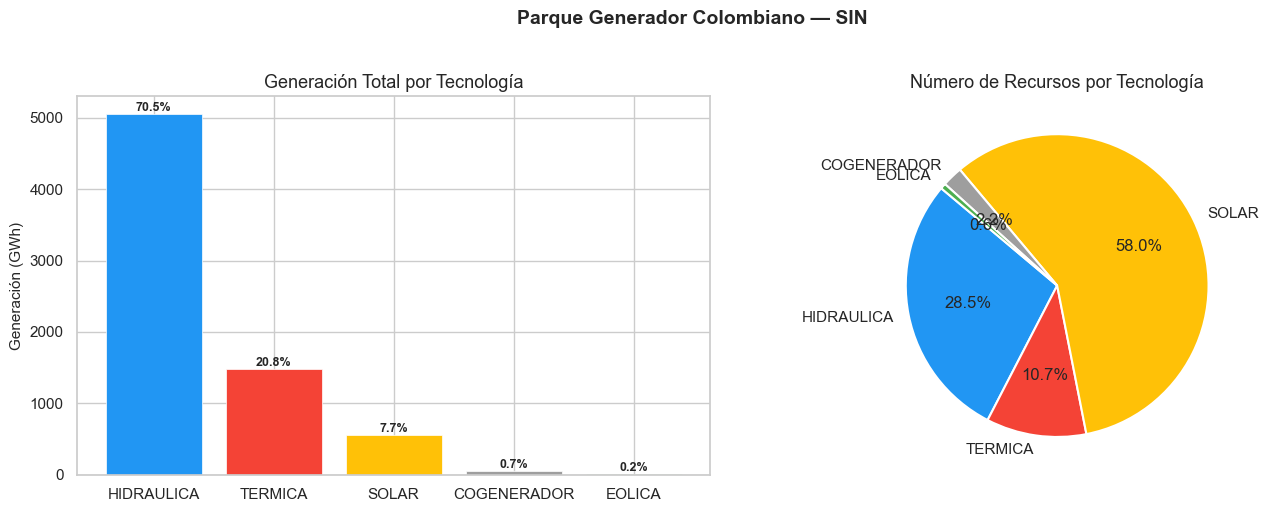

💡 Insight: A pesar de que la SOLAR representa ~56% de los recursos del SIN,
   se evidencia que el uso de energía HIDRÍCA re presenta un 76% de la generación. Esto refleja que la mayoría de
   los recursos solares son pequeñas instalaciones de GD y autogeneración.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Barras de generación total ──
colores = {"HIDRAULICA": "#2196F3", "SOLAR": "#FFC107", "TERMICA": "#F44336",
           "EOLICA": "#4CAF50", "COGENERADOR": "#9E9E9E"}
bar_colors = [colores.get(t, "#9E9E9E") for t in resumen_tecnologia["Tecnologia"]]

bars = axes[0].bar(
    resumen_tecnologia["Tecnologia"],
    resumen_tecnologia["Generacion_Total_MWh"] / 1e3,  # → GWh
    color=bar_colors, edgecolor="white", linewidth=0.5
)
for bar, pct in zip(bars, resumen_tecnologia["Participacion_%"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{pct}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Generación Total por Tecnología")
axes[0].set_ylabel("Generación (GWh)")
axes[0].set_xlabel("")

# ── Gráfico 2: Pie de número de recursos ──
pie_colors = [colores.get(t, "#9E9E9E") for t in resumen_tecnologia["Tecnologia"]]
axes[1].pie(
    resumen_tecnologia["Num_Recursos"],
    labels=resumen_tecnologia["Tecnologia"],
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Número de Recursos por Tecnología")

fig.suptitle("Parque Generador Colombiano — SIN", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig01_generacion_por_tecnologia.png"), dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: A pesar de que la SOLAR representa ~56% de los recursos del SIN,")
print("   se evidencia que el uso de energía HIDRÍCA re presenta un 76% de la generación. Esto refleja que la mayoría de")
print("   los recursos solares son pequeñas instalaciones de GD y autogeneración.")

### 4.2 Perfil Horario: Complementariedad Solar–Hidráulica

La generación solar presenta una **curva de campana** característica: producción nula en horas nocturnas, rampa de subida desde las 06h, pico entre las 10h–14h, y descenso hasta las 18h.

La **complementariedad solar–hidráulica** es clave para la seguridad energética: mientras la solar reduce la demanda sobre el sistema en horas de sol, la hidráulica mantiene generación estable las 24 horas y cubre los picos de demanda nocturna (18h–22h).

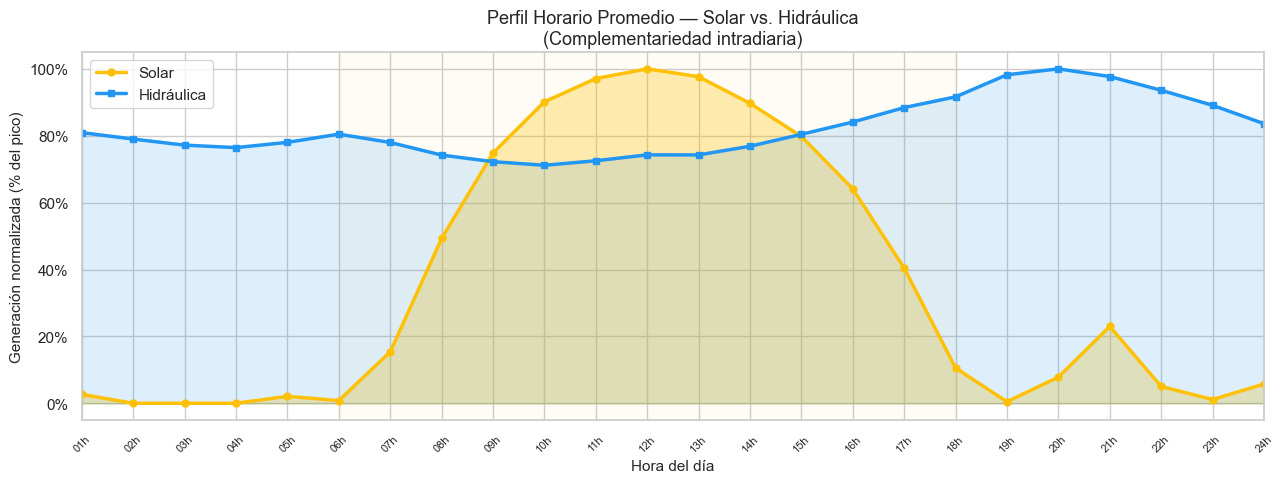

💡 Insight: El perfil solar tiene su pico entre las 09h-15h. La hidroeléctrica
   muestra mayor generación en horas pico de demanda (18h-22h), confirmando
   la complementariedad Solar + Hidráulica que hace tan valiosa la solar en Colombia.


In [27]:
# Filtrar solo recursos solares y calcular perfil horario promedio
gen_solar = gen_enriquecida[gen_enriquecida["Tecnologia"] == "SOLAR"].copy()
gen_hidro = gen_enriquecida[gen_enriquecida["Tecnologia"] == "HIDRAULICA"].copy()

perfil_solar = gen_solar.groupby("Hora")["Generacion_kWh"].mean().reset_index()
perfil_hidro = gen_hidro.groupby("Hora")["Generacion_kWh"].mean().reset_index()

# Normalizar a porcentaje del pico para comparar perfiles en la misma escala
perfil_solar["Gen_Norm_%"] = perfil_solar["Generacion_kWh"] / perfil_solar["Generacion_kWh"].max() * 100
perfil_hidro["Gen_Norm_%"] = perfil_hidro["Generacion_kWh"] / perfil_hidro["Generacion_kWh"].max() * 100

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(perfil_solar["Hora"], perfil_solar["Gen_Norm_%"],
                alpha=0.3, color="#FFC107", label="_nolegend_")
ax.plot(perfil_solar["Hora"], perfil_solar["Gen_Norm_%"],
        color="#FFC107", lw=2.5, marker="o", ms=5, label="Solar")

ax.fill_between(perfil_hidro["Hora"], perfil_hidro["Gen_Norm_%"],
                alpha=0.15, color="#2196F3", label="_nolegend_")
ax.plot(perfil_hidro["Hora"], perfil_hidro["Gen_Norm_%"],
        color="#2196F3", lw=2.5, marker="s", ms=5, label="Hidráulica")

ax.axvspan(6, 18, alpha=0.04, color="#FFC107")  # Franja horaria solar
ax.set_xlim(1, 24)
ax.set_xticks(range(1, 25))
ax.set_xticklabels([f"{h:02d}h" for h in range(1, 25)], rotation=45, fontsize=8)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Generación normalizada (% del pico)")
ax.set_title("Perfil Horario Promedio — Solar vs. Hidráulica\n(Complementariedad intradiaria)")
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig02_perfil_horario_solar_hidro.png"), dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: El perfil solar tiene su pico entre las 09h-15h. La hidroeléctrica")
print("   muestra mayor generación en horas pico de demanda (18h-22h), confirmando")
print("   la complementariedad Solar + Hidráulica que hace tan valiosa la solar en Colombia.")

### 4.3 Concentración del Mercado por Agente

Un indicador clave de competitividad del mercado eléctrico es el grado de concentración de la generación. El análisis de los **Top 15 agentes** permite identificar si el mercado mayorista está dominado por pocos actores y cómo se distribuye su portafolio tecnológico.

In [17]:
gen_enriquecida.columns

Index(['Fecha', 'Hora', 'Codigo_Planta', 'Generacion_kWh', 'Nombre_Planta',
       'Tecnologia', 'Fuente_Energia', 'Codigo_Agente', 'Tipo_Despacho',
       'Tipo_Recurso', 'Fecha_Inicio_Op', 'Estado'],
      dtype='object')

In [18]:
# Generación total por agente
gen_por_agente = (
    gen_enriquecida
    .groupby(["Codigo_Agente", "Tecnologia"])["Generacion_kWh"]
    .sum()
    .div(1e6)  # kWh → GWh (más legible)
    .reset_index()
    .rename(columns={"Generacion_kWh": "Generacion_GWh"})
)

gen_por_agente.head()

,Codigo_Agente,Tecnologia,Generacion_GWh
0,AAGG,SOLAR,12.823049
1,ABAG,HIDRAULICA,5.697535
2,ADCG,HIDRAULICA,4.637337
3,BCCG,SOLAR,1.393270
4,BDJG,TERMICA,0.979197


In [19]:
# Top 15 agentes por generación total (todas las tecnologías)
top_agentes = (
    gen_por_agente
    .groupby("Codigo_Agente")["Generacion_GWh"]
    .sum()
    .nlargest(15)
    .reset_index()
)

top_agentes.head()

,Codigo_Agente,Generacion_GWh
0,EPMG,1751.088496
1,ENDG,1642.209909
2,ISGG,1043.226568
3,CHVG,445.885092
4,EPSG,339.836095


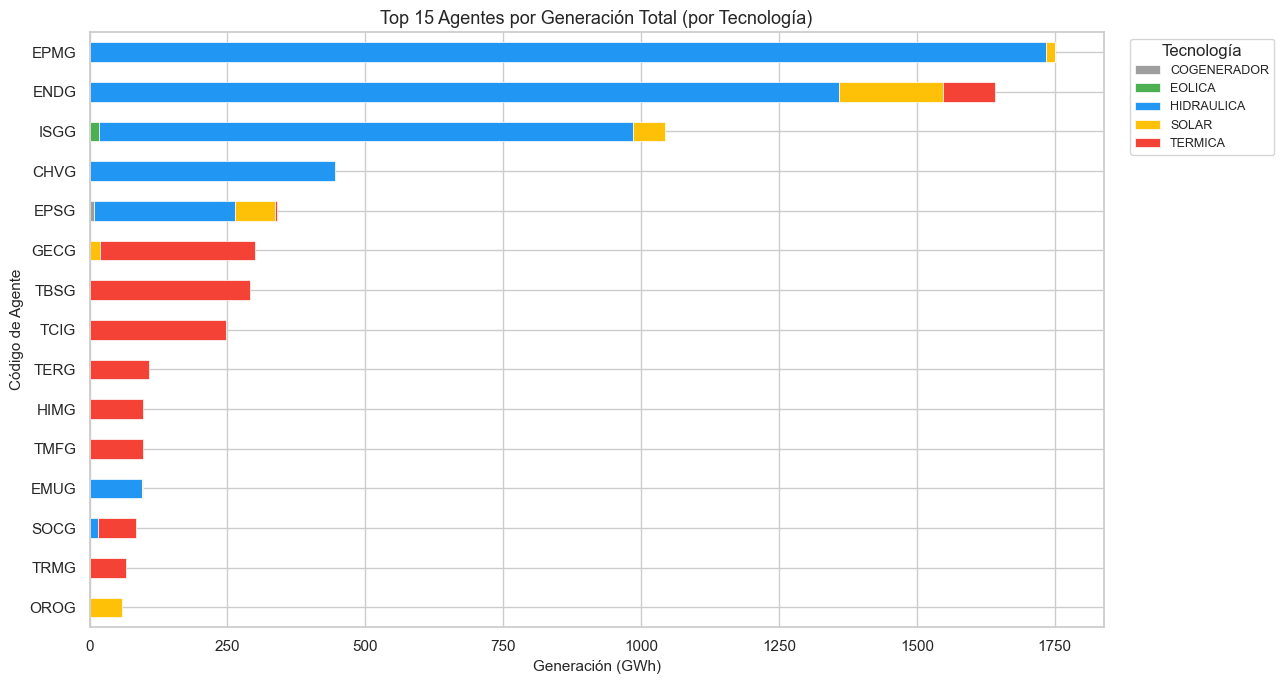

In [20]:
# Filtrar datos del gráfico apilado
gen_top_apilado = gen_por_agente[gen_por_agente["Codigo_Agente"].isin(top_agentes["Codigo_Agente"])]
tabla_pivot = gen_top_apilado.pivot_table(
    index="Codigo_Agente", columns="Tecnologia", values="Generacion_GWh", aggfunc="sum", fill_value=0
).reindex(top_agentes["Codigo_Agente"])

# Gráfico de barras apiladas
ax = tabla_pivot.plot(
    kind="barh",
    stacked=True,
    color=[colores.get(c, "#9E9E9E") for c in tabla_pivot.columns],
    figsize=(13, 7),
    edgecolor="white",
    linewidth=0.5
)

ax.set_xlabel("Generación (GWh)")
ax.set_ylabel("Código de Agente")
ax.set_title("Top 15 Agentes por Generación Total (por Tecnología)")
ax.legend(title="Tecnología", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.invert_yaxis()  # Mayor generador arriba
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig03_top_agentes_generacion.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Desglose por Tipo de Recurso (RecType)

La columna `Tipo_Recurso` clasifica de forma más granular que `Tecnologia` lo cual hace que se pueda visualizar de mejor forma la **estructura real del parque generador colombiano**, especialmente en las FNCER:

| RecType | Descripción |
|---------|-------------|
| `AUTOG PEQ. ESCALA` | Autogeneradores de pequeña escala (< 1 MW, CREG 174-2021) |
| `GEN. DISTRIBUIDA`  | Generación Distribuida conectada a redes de distribución |
| `AUTOGENERADOR`     | Grandes autogeneradores industriales (> 1 MW) |
| `NORMAL`            | Plantas despachadas centralmente por XM |
| `FILO DE AGUA`      | Pequeñas centrales hidroeléctricas sin embalse |
| `CICLO COMBINADO`   | Termoeléctricas de alta eficiencia |
| `COGENERADOR`       | Co-generación (calor + electricidad) |

**¿Por qué es importante esta consideración?**  
Teniendo en cuenta que se presentan variados tipos de unidades de generación el sector eléctrico colombiano clasificadas por las resoluciones CREG como la`AUTOG PEQ. ESCALA` y `GEN. DISTRIBUIDA`, las cuales son fundamentalmente distintas a las plantas catalogadas como`NORMAL` en términos de regulación (CREG), despacho y remuneración.

In [21]:
# ── Generación por Tipo de Recurso (todas las tecnologías) ──────────────────
resumen_rectype = (
    gen_enriquecida
    .groupby(["Tecnologia", "Tipo_Recurso"])
    .agg(
        Generacion_GWh=("Generacion_kWh", lambda x: x.sum() / 1e6),
        Num_Recursos=("Codigo_Planta", "nunique"),
    )
    .reset_index()
    .sort_values(["Tecnologia", "Generacion_GWh"], ascending=[True, False])
)

print("Generación y recursos por Tecnología + Tipo de Recurso:")
print(resumen_rectype.to_string(index=False))

Generación y recursos por Tecnología + Tipo de Recurso:
 Tecnologia       Tipo_Recurso  Generacion_GWh  Num_Recursos
COGENERADOR        COGENERADOR       52.960435            11
     EOLICA             NORMAL       17.256511             3
 HIDRAULICA             NORMAL     4761.984559           113
 HIDRAULICA       FILO DE AGUA      229.031656            13
 HIDRAULICA FILO AGUA ESPECIAL       32.985172             1
 HIDRAULICA      AUTOGENERADOR       18.180034             5
 HIDRAULICA   GEN. DISTRIBUIDA        4.022421            12
      SOLAR             NORMAL      508.545956           102
      SOLAR      AUTOGENERADOR       25.255232            31
      SOLAR   GEN. DISTRIBUIDA       20.012682           156
      SOLAR  AUTOG PEQ. ESCALA        0.135407             4
    TERMICA             NORMAL      833.405183            33
    TERMICA    CICLO COMBINADO      636.113642             5
    TERMICA      AUTOGENERADOR       14.394704            14
    TERMICA  AUTOG PEQ. ESCAL

---
## 🗓️ Sección 5: Evolución Diaria de la Generación

Aunque el período de muestra es corto (3 días), este análisis establece la base para la versión v2, donde se trabajará con series de tiempo de 30+ días para detectar tendencias y anomalías.

### 5.1 Evolución Diaria por Tecnología

Área apilada de la generación total del SIN día a día, desglosada por **tecnología de generación**.
Permite identificar de un vistazo:
- El **peso relativo** de cada tecnología en el balance diario.
- **Variabilidad** de la generación térmica (que opera como respaldo) frente a la estabilidad hídrica.
- La **línea punteada del Total SIN** como referencia del sistema completo.

> El eje X es adaptativo: ajusta automáticamente la densidad de marcas según el rango del período
> analizado (días, semanas o meses), evitando el solapamiento de etiquetas.

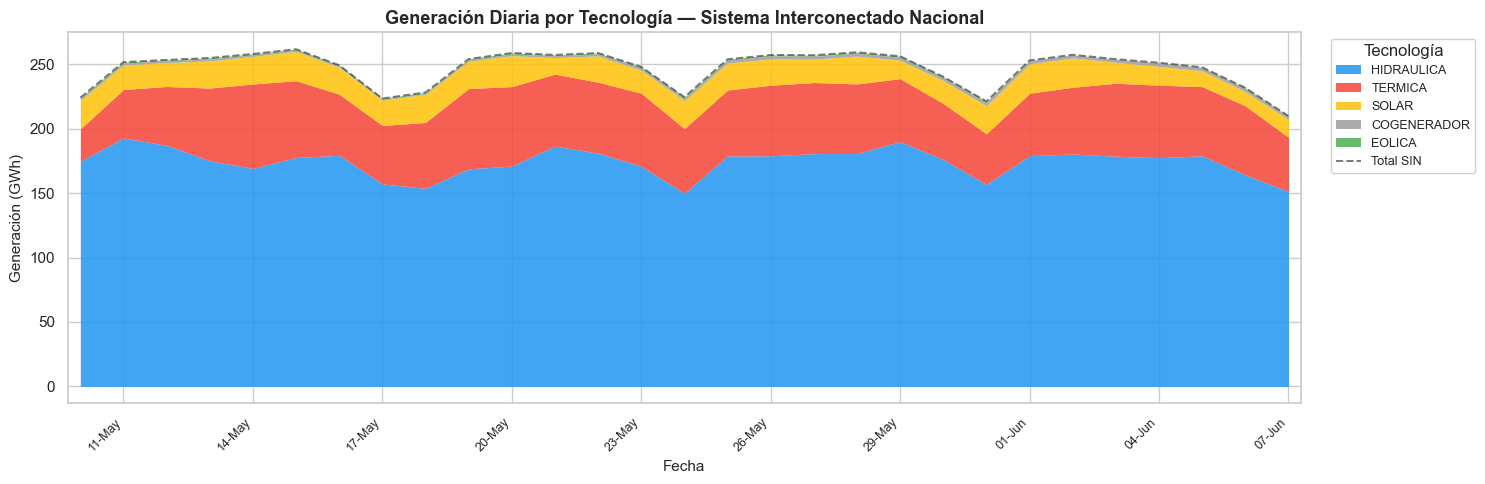

In [22]:
import matplotlib.dates as mdates

gen_diaria = (
    gen_enriquecida
    .groupby(["Fecha", "Tecnologia"])["Generacion_kWh"]
    .sum()
    .div(1e6)  # kWh → GWh
    .reset_index()
    .rename(columns={"Generacion_kWh": "Generacion_GWh"})
)

# Ordenar tecnologías de mayor a menor aporte para el apilado
orden_tec = (gen_diaria.groupby("Tecnologia")["Generacion_GWh"]
             .sum().sort_values(ascending=False).index.tolist())

# Pivot con índice datetime real (necesario para mdates)
tabla_diaria = (gen_diaria
                .pivot_table(index="Fecha", columns="Tecnologia",
                             values="Generacion_GWh", aggfunc="sum")
                .fillna(0)
                .reindex(columns=orden_tec))
tabla_diaria.index = pd.to_datetime(tabla_diaria.index)

# ── Gráfico: área apilada ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))

tecnologias_plot = tabla_diaria.columns.tolist()
colores_plot     = [colores.get(t, "#9E9E9E") for t in tecnologias_plot]

# Acumular manualmente para el fill_between apilado
acum = pd.Series(0.0, index=tabla_diaria.index)
for tec, color in zip(tecnologias_plot, colores_plot):
    ax.fill_between(tabla_diaria.index,
                    acum.values, (acum + tabla_diaria[tec]).values,
                    label=tec, color=color, alpha=0.85, linewidth=0)
    acum = acum + tabla_diaria[tec]

# Línea del total del sistema
ax.plot(tabla_diaria.index, acum.values, color="#333333",
        linewidth=1.4, linestyle="--", label="Total SIN", alpha=0.65)

# ── Eje X adaptativo: intervalo según duración del período ───────────────────
n_dias = (tabla_diaria.index[-1] - tabla_diaria.index[0]).days

if n_dias <= 10:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
elif n_dias <= 31:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
elif n_dias <= 90:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Lunes
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
else:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)

ax.set_title("Generación Diaria por Tecnología — Sistema Interconectado Nacional",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Generación (GWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Tecnología", bbox_to_anchor=(1.02, 1),
          loc="upper left", fontsize=9, framealpha=0.9)
ax.margins(x=0.01)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig04_generacion_diaria.png"), dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Evolución Diaria por Tipo de Recurso (RecType)

El mismo gráfico de área apilada pero con una granularidad mayor: **tipo de recurso** en lugar
de tecnología. Esto separa, por ejemplo, las plantas solares `NORMAL` (grandes, despacho central)
de los recursos `GEN. DISTRIBUIDA` y `AUTOG PEQ. ESCALA` (pequeña escala, no despachados).

**Paleta de colores — criterio de diseño:**

| Color | RecType | Lógica |
|-------|---------|--------|
| 🟦 Azul `#2196F3` | `NORMAL` | Despacho centralizado — el grueso de la energía |
| 🔴 Rojo `#EF5350` | `CICLO COMBINADO` | Térmica de alta eficiencia |
| 🔵 Azul claro `#90CAF9` | `FILO DE AGUA` | Pequeñas hidro sin embalse |
| 🟠 Naranja `#FF8F00` | `AUTOGENERADOR` | Industrial, > 1 MW, no despachado |
| 🟡 Amarillo `#FFC107` | `GEN. DISTRIBUIDA` | Solar GD conectada a distribución |
| 🟨 Amarillo claro `#FFE082` | `AUTOG PEQ. ESCALA` | Solar < 1 MW (CREG 174-2021) |
| ⬜ Gris `#9E9E9E` | `COGENERADOR` | Co-generación industrial |

> La escasez de amarillo en el área apilada —pese a que solar representa ~84 % de los recursos
> del SIN— confirma visualmente que la mayoría son instalaciones de pequeña escala con baja
> energía individual.

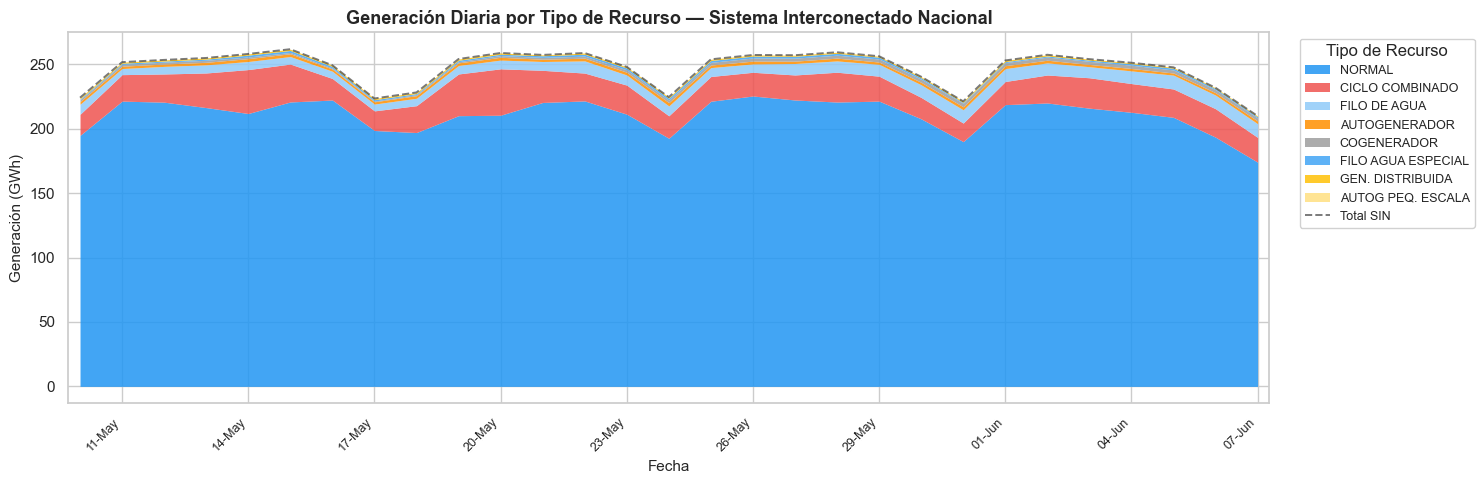

In [23]:
import matplotlib.dates as mdates

# Paleta de colores por Tipo de Recurso
paleta_rectype = {
    "AUTOG PEQ. ESCALA":  "#FFE082",  # Amarillo claro  — solar pequeña escala
    "GEN. DISTRIBUIDA":   "#FFC107",  # Amarillo medio  — solar GD
    "AUTOGENERADOR":      "#FF8F00",  # Naranja         — autogenerador industrial
    "NORMAL":             "#2196F3",  # Azul            — despacho central
    "FILO DE AGUA":       "#90CAF9",  # Azul claro      — pequeñas hidro
    "FILO AGUA ESPECIAL": "#42A5F5",
    "CICLO COMBINADO":    "#EF5350",  # Rojo            — térmica eficiente
    "COGENERADOR":        "#9E9E9E",  # Gris
}
color_default = "#B0BEC5"

# Aggregation por Tipo_Recurso
gen_diaria_rectype = (
    gen_enriquecida
    .groupby(["Fecha", "Tipo_Recurso"])["Generacion_kWh"]
    .sum()
    .div(1e6)  # kWh → GWh
    .reset_index()
    .rename(columns={"Generacion_kWh": "Generacion_GWh"})
)

# Ordenar de mayor a menor aporte para el apilado
orden_rectype = (gen_diaria_rectype.groupby("Tipo_Recurso")["Generacion_GWh"]
                 .sum().sort_values(ascending=False).index.tolist())

tabla_rectype = (gen_diaria_rectype
                 .pivot_table(index="Fecha", columns="Tipo_Recurso",
                              values="Generacion_GWh", aggfunc="sum")
                 .fillna(0)
                 .reindex(columns=orden_rectype))
tabla_rectype.index = pd.to_datetime(tabla_rectype.index)

# ── Gráfico: área apilada ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))

colores_plot = [paleta_rectype.get(t, color_default) for t in tabla_rectype.columns]

acum = pd.Series(0.0, index=tabla_rectype.index)
for tec, color in zip(tabla_rectype.columns, colores_plot):
    ax.fill_between(tabla_rectype.index,
                    acum.values, (acum + tabla_rectype[tec]).values,
                    label=tec, color=color, alpha=0.85, linewidth=0)
    acum = acum + tabla_rectype[tec]

ax.plot(tabla_rectype.index, acum.values, color="#333333",
        linewidth=1.4, linestyle="--", label="Total SIN", alpha=0.65)

# Eje X adaptativo según duración del período
n_dias = (tabla_rectype.index[-1] - tabla_rectype.index[0]).days
if n_dias <= 10:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
elif n_dias <= 31:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
elif n_dias <= 90:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
else:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)

ax.set_title("Generación Diaria por Tipo de Recurso — Sistema Interconectado Nacional",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Generación (GWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Tipo de Recurso", bbox_to_anchor=(1.02, 1),
          loc="upper left", fontsize=9, framealpha=0.9)
ax.margins(x=0.01)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig05_generacion_diaria_rectype.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 📋 Sección 6 — Resumen y Roadmap

### Resultados de la versión 1

- ✅ **Pipeline ETL reproducible:** extracción desde la API XM vía `pydataxm` → modelo dimensional limpio (star schema).
- ✅ **Modelo dimensional:** `fact_generacion` + `dim_plantas` + `dim_agentes` + `dim_rios`.
- ✅ **3 modos de operación:** `API` (últimos 30 días), `FIJO` (rango personalizado), `CSV` (offline).
- ✅ **Auto-refresh de catálogos:** detección automática de plantas sin match → descarga de catálogos frescos → re-JOIN.
- ✅ **Versionamiento de catálogos:** archivos con estampa `YYYYMMDD` + función `comparar_catalogos()` para tracking de cambios.
- ✅ **EDA completo:** distribución por tecnología, perfil horario solar–hidráulica, concentración por agente, desglose por RecType.
- ✅ **Archivos limpios** exportados en `data/processed/` con estampa temporal, listos para dashboards.

### Roadmap del proyecto

| Versión | Enfoque | Métricas XM nuevas | Estado |
|---------|---------|---------------------|--------|
| **v1 (actual)** | ETL + EDA + auto-refresh catálogos | `Gene`, `ListadoRecursos`, `ListadoAgentes`, `ListadoRios` | ✅ |
| **v2** | Series 30+ días · Balance generación-demanda · Precio de bolsa · Nivel de embalses | `DemaReal`, `PrecBolsNaci`, `PorcVoluUtilDiar`, `AporEner` | ⏭️ Próxima |
| **v2.5** | Caso de negocio: arbitraje de energía con SAEB, bajo la Resolución CREG 101 113 de 2026 (almacenamiento con baterías) | `PrecBolsNaci` (reutilizada de v2) | 🆕 Propuesta |
| **v3** | Análisis ESG · Emisiones CO₂ · Capacidad instalada · Factor de planta | `EmisionesCO2Eq`, `CapEfecNeta`, `IrrGlobal`, `factorEmisionCO2e` | 📋 |
| **v4** | Dashboard interactivo Streamlit | — | 📋 |
| **v5** | Modelo predictivo: `GeneProgDesp` vs `Gene` → desviaciones → ML predicción solar | `GeneProgDesp`, `DesvEner` | 📋 |

---
## 🔧 Anexo A — Actualización Manual de Catálogos

La función `actualizar_catalogos_maestros()` fue definida en la Sección 2. En el caso de que se requiera ejecutar manualmente, se puede hacer cuando se necesite forzar una actualización fuera del flujo automático del ETL.

In [24]:
# La función actualizar_catalogos_maestros() ya fue definida en la Sección 2.
# Para ejecutar una actualización manual, descomenta la siguiente línea:

# actualizar_catalogos_maestros(RAW_DIR)

print("ℹ️  actualizar_catalogos_maestros() definida en Sección 2.")
print("   Para actualización manual, descomenta la línea de arriba.")

ℹ️  actualizar_catalogos_maestros() definida en Sección 2.
   Para actualización manual, descomenta la línea de arriba.


---
## 🔍 Anexo B: Comparación de Versiones de Catálogos

Los catálogos `dim_plantas`, `dim_agentes` y `dim_rios` **no son estáticos**.
XM puede agregar nuevos recursos (plantas solares que entran en operación, nuevos agentes),
modificar información existente, o dar de baja recursos.

La función `comparar_catalogos()` permite detectar estos cambios entre dos fechas,
lo cual es valioso para:
- **Seguimiento de mercado**: ¿cuántas plantas solares nuevas entraron este mes?
- **Trazabilidad del portafolio**: ¿cambió el agente propietario de alguna planta?
- **Análisis regulatorio**: ¿hay nuevos agentes desde la implementación de CREG 174-2021?

In [25]:
# Llaves primarias de cada catálogo para identificar registros únicos
LLAVES_CATALOGOS = {
    "plantas": "Values_Code",   # Código único de cada recurso generador
    "agentes": "Values_Code",   # Código único de cada agente del mercado
    "rios":    "Values_Code",   # Código único de cada río/cuenca
}

# Columnas que son metadatos de la API (no del recurso) → excluir de la comparación
COLS_EXCLUIR_COMPARACION = {"Date", "Id"}


def comparar_catalogos(
    directorio: str,
    nombre: str,
    fecha_base: str,
    fecha_nueva: str,
    verbose: bool = True
) -> dict:
    """
    Compara dos versiones de un catálogo maestro e identifica entradas
    nuevas, eliminadas y modificadas entre las dos fechas.

    Args:
        directorio  : Carpeta donde están los CSV (ej. 'data/raw').
        nombre      : Catálogo a comparar: 'plantas', 'agentes' o 'rios'.
        fecha_base  : Fecha de la versión anterior en formato 'YYYYMMDD'.
        fecha_nueva : Fecha de la versión nueva en formato 'YYYYMMDD'.
        verbose     : Si True, imprime el reporte completo.

    Returns:
        Diccionario con keys: 'nuevos', 'eliminados', 'modificados', 'sin_cambios'
        Cada value es un DataFrame con los registros correspondientes.

    Ejemplo:
        resultado = comparar_catalogos(RAW_DIR, 'plantas', '20260413', '20260609')
        plantas_nuevas = resultado['nuevos']
    """
    llave = LLAVES_CATALOGOS.get(nombre)
    if llave is None:
        raise ValueError(f"Nombre inválido: '{nombre}'. Opciones: {list(LLAVES_CATALOGOS.keys())}")

    # Cargar las dos versiones
    ruta_base  = os.path.join(directorio, f"dim_{nombre}_{fecha_base}.csv")
    ruta_nueva = os.path.join(directorio, f"dim_{nombre}_{fecha_nueva}.csv")

    for ruta in [ruta_base, ruta_nueva]:
        if not os.path.exists(ruta):
            raise FileNotFoundError(
                f"Archivo no encontrado: {ruta}\n"
                f"Asegúrate de haber ejecutado actualizar_catalogos_maestros() en ambas fechas."
            )

    df_base  = pd.read_csv(ruta_base)
    df_nueva = pd.read_csv(ruta_nueva)

    ids_base  = set(df_base[llave].dropna().astype(str))
    ids_nueva = set(df_nueva[llave].dropna().astype(str))

    # Conjuntos de cambio
    ids_nuevos     = ids_nueva - ids_base      # Entraron
    ids_eliminados = ids_base - ids_nueva      # Salieron
    ids_comunes    = ids_base & ids_nueva      # Estaban en ambas

    # ── Detectar modificaciones en registros comunes ─────────────────────────
    # drop_duplicates: la API de XM puede retornar el mismo código más de una
    # vez (ej: dim_agentes tiene registros OPERACION + INACTIVO para el mismo
    # código). Nos quedamos con la primera ocurrencia.
    df_base_dedup  = (df_base[df_base[llave].astype(str).isin(ids_comunes)]
                      .drop_duplicates(subset=llave, keep="first"))
    df_nueva_dedup = (df_nueva[df_nueva[llave].astype(str).isin(ids_comunes)]
                      .drop_duplicates(subset=llave, keep="first"))

    # Columnas a comparar: excluir la llave (será el índice), Date e Id (metadatos API)
    excluir = COLS_EXCLUIR_COMPARACION | {llave}
    cols_comunes = [c for c in df_base_dedup.columns
                    if c in df_nueva_dedup.columns and c not in excluir]

    df_base_alin  = df_base_dedup.set_index(llave)[cols_comunes].astype(str).sort_index()
    df_nueva_alin = df_nueva_dedup.set_index(llave)[cols_comunes].astype(str).sort_index()

    # Asegurar que ambos DataFrames tengan exactamente los mismos índices
    idx_comun = df_base_alin.index.intersection(df_nueva_alin.index)
    df_base_alin  = df_base_alin.loc[idx_comun]
    df_nueva_alin = df_nueva_alin.loc[idx_comun]

    mascara_mod = ~(df_base_alin == df_nueva_alin).all(axis=1)
    ids_modificados = set(mascara_mod[mascara_mod].index.astype(str))
    ids_sin_cambios = ids_comunes - ids_modificados

    # Construir DataFrames de resultado
    resultado = {
        "nuevos":      df_nueva[df_nueva[llave].astype(str).isin(ids_nuevos)].reset_index(drop=True),
        "eliminados":  df_base[df_base[llave].astype(str).isin(ids_eliminados)].reset_index(drop=True),
        "modificados": df_nueva[df_nueva[llave].astype(str).isin(ids_modificados)].reset_index(drop=True),
        "sin_cambios": df_nueva[df_nueva[llave].astype(str).isin(ids_sin_cambios)].reset_index(drop=True),
    }

    if verbose:
        print(f"\n{'─'*60}")
        print(f"  📊 Comparación: dim_{nombre}")
        print(f"     Base  ({fecha_base}): {len(df_base):>5} registros")
        print(f"     Nueva ({fecha_nueva}): {len(df_nueva):>5} registros")
        print(f"{'─'*60}")
        print(f"  ✅ Sin cambios:    {len(resultado['sin_cambios']):>5}")
        print(f"  🆕 Nuevos:         {len(resultado['nuevos']):>5}")
        print(f"  ❌ Eliminados:     {len(resultado['eliminados']):>5}")
        print(f"  ✏️  Modificados:   {len(resultado['modificados']):>5}")
        print(f"  ℹ️  Columnas excluidas: {COLS_EXCLUIR_COMPARACION}")
        print(f"{'─'*60}")

        if not resultado['nuevos'].empty:
            cols_show = [c for c in [llave, 'Values_Name', 'Values_Type',
                                     'Values_EnerSource', 'Values_CompanyCode']
                         if c in resultado['nuevos'].columns]
            n_mostrar = min(20, len(resultado['nuevos']))
            print(f"\n  🆕 NUEVOS ({len(resultado['nuevos'])} registros, mostrando {n_mostrar}):")
            print(resultado['nuevos'][cols_show].head(n_mostrar).to_string(index=False))
            if len(resultado['nuevos']) > n_mostrar:
                print(f"    ... y {len(resultado['nuevos']) - n_mostrar} más.")

        if not resultado['eliminados'].empty:
            cols_show = [c for c in [llave, 'Values_Name', 'Values_Type',
                                     'Values_EnerSource', 'Values_CompanyCode']
                         if c in resultado['eliminados'].columns]
            print(f"\n  ❌ ELIMINADOS ({len(resultado['eliminados'])}):")
            print(resultado['eliminados'][cols_show].to_string(index=False))

        if not resultado['modificados'].empty:
            n_mostrar = min(30, len(resultado['modificados']))
            print(f"\n  ✏️  MODIFICADOS ({len(resultado['modificados'])} registros, mostrando {n_mostrar}):")
            for idx, (_, row) in enumerate(resultado['modificados'].iterrows()):
                if idx >= n_mostrar:
                    print(f"    ... y {len(resultado['modificados']) - n_mostrar} más.")
                    break
                cod = str(row[llave])
                if cod in df_base_alin.index and cod in df_nueva_alin.index:
                    fb = df_base_alin.loc[cod]
                    fn = df_nueva_alin.loc[cod]
                    diffs = [col for col in cols_comunes if fb[col] != fn[col]]
                    nombre_rec = row.get('Values_Name', cod)
                    if diffs:
                        print(f"    [{cod}] {nombre_rec}: cambios en → {diffs}")

    return resultado


def comparar_todos_los_catalogos(
    directorio: str,
    fecha_base: str,
    fecha_nueva: str
) -> dict:
    """
    Ejecuta comparar_catalogos() para los tres catálogos de una sola vez.

    Args:
        directorio  : Carpeta donde están los CSV.
        fecha_base  : Fecha de la versión anterior (YYYYMMDD).
        fecha_nueva : Fecha de la versión nueva (YYYYMMDD).

    Returns:
        Diccionario {'plantas': {...}, 'agentes': {...}, 'rios': {...}}
    """
    print(f"\n🔍 Comparando catálogos: {fecha_base} → {fecha_nueva}\n")
    resultados = {}
    for nombre in LLAVES_CATALOGOS:
        try:
            resultados[nombre] = comparar_catalogos(directorio, nombre, fecha_base, fecha_nueva)
        except FileNotFoundError as e:
            print(f"  ⚠️  Omitiendo '{nombre}': {e}")
    return resultados


# ── Ejemplo de uso ────────────────────────────────────────────────────────────
# Descomenta y ajusta las fechas para comparar dos snapshots:
#
resultado = comparar_todos_los_catalogos(
    directorio  = RAW_DIR,
    fecha_base  = "20260413",
    fecha_nueva = "20260609",
)
#
# Para acceder a los resultados individuales:
# plantas_nuevas     = resultado['plantas']['nuevos']
# agentes_eliminados = resultado['agentes']['eliminados']
# rios_modificados   = resultado['rios']['modificados']
print("✅ Funciones comparar_catalogos() y comparar_todos_los_catalogos() listas.")
print("   Descomenta el bloque de ejemplo y ajusta las fechas para usarlas.")


🔍 Comparando catálogos: 20260413 → 20260609


────────────────────────────────────────────────────────────
  📊 Comparación: dim_plantas
     Base  (20260413):  1598 registros
     Nueva (20260609):  2212 registros
────────────────────────────────────────────────────────────
  ✅ Sin cambios:     1577
  🆕 Nuevos:           615
  ❌ Eliminados:         1
  ✏️  Modificados:      20
  ℹ️  Columnas excluidas: {'Date', 'Id'}
────────────────────────────────────────────────────────────

  🆕 NUEVOS (615 registros, mostrando 20):
Values_Code                              Values_Name Values_Type Values_EnerSource Values_CompanyCode
       3HCS                         AGPE FRIGOCAFE 1       SOLAR         RAD SOLAR               GNCC
       3HCV          AGPE ALCON DE COLOMBIA PABM SAS       SOLAR         RAD SOLAR               EPSC
       3HCX                 AGPE PROPILFLEX DISGOMEZ       SOLAR         RAD SOLAR               EPSC
       3HCZ                       AGPE SERO COLOMBIA       SOLAR  